# Image Classification

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Images as Economic Data

- A satellite chip is **unstructured data**, $64 \times 64 \times 3$ numbers. A classifier turns it into a variable: built-up or agricultural land, roads, forest, water ([Donaldson and Storeygard 2016](https://www.aeaweb.org/articles?id=10.1257/jep.30.4.171))
- The classifier is a **measuring instrument**: its mistakes are measurement error in any regression the labels enter, and here they vary with the landscape and the prompt. The [classification lecture](classification.qmd#/predictions-as-measurements) covers what that does and how to correct it
- Two routes, neither of which trains anything: a **vision-language model** through Ollama (the [local LLM lecture](local_llms.qmd), with `qwen3.5:4b` pulled, or `qwen3.5:2b` on 8 GB machines) and a **downloaded classifier** trained for exactly this task (`uv sync --extra extras` for `torch` and `transformers`)

# EuroSAT

## The Data

- [EuroSAT](https://arxiv.org/abs/1709.00029) (Helber, Bischke, Dengel, and Borth 2019): $27{,}000$ Sentinel-2 chips, $64 \times 64$ pixels at $10$ m, ten land-use classes; $92$ MB on the Hub as [`cm93/eurosat`](https://huggingface.co/datasets/cm93/eurosat)
- `load_dataset` downloads it once. The test rows are in random order, so the first $100$ are a sample

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

chips = load_dataset("cm93/eurosat", split="test[:100]")
labels = chips.features["label"].names
truth = [labels[i] for i in chips["label"]]
print(chips[0]["image"].size, truth[0])

(64, 64) SeaLake

- Each observation is $(x_n, y_n)$, an image and a class. No hand-built features

## Ten Chips

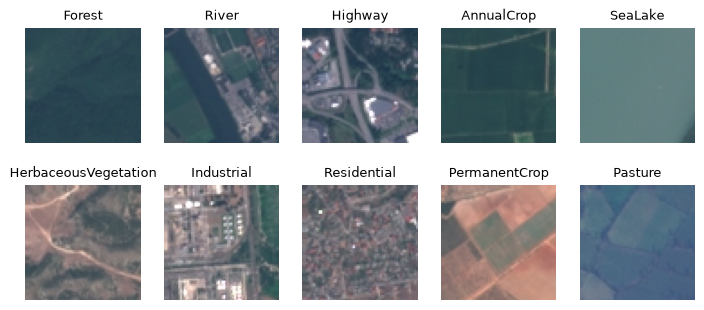

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 3.9))
for ax, label in zip(axes.flat, labels):
    ax.imshow(chips[truth.index(label)]["image"])
    ax.set_title(label, fontsize=10)
    ax.axis("off")
plt.show()

- Each chip covers $640$ m on a side. Some classes are obvious at this resolution; `Pasture`, `HerbaceousVegetation`, and `PermanentCrop` are not, even for a person

# A Vision-Language Model

## Can a Language Model See?

- A **vision-language model** adds a vision encoder that cuts the image into patches and maps each to a vector in the token space. The transformer reads image and text together and generates text
- Qwen 3.5, the local LLM lecture’s model, is built this way, so the chat call already accepts images

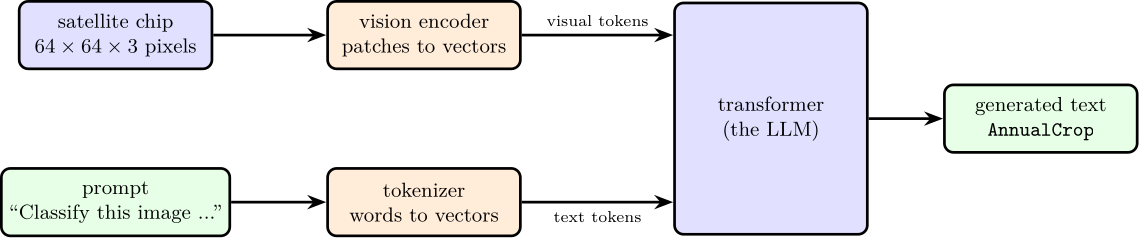

## Two Ways to Connect Pixels and Words

- **Embedding models** ([CLIP](https://arxiv.org/abs/2103.00020), and [RemoteCLIP](https://arxiv.org/abs/2306.11029) for satellite imagery) put images and text in one vector space. Embed the chip and each label, pick the closest: a **zero-shot classifier** in the spirit of the [embeddings lecture](nlp_llm.qmd)
- **Generative models** (Qwen 3.5, Qwen3-VL, GPT-4o, Gemini) put the visual tokens in front of the LLM and generate the label as text, given the image, a question, and the allowed labels
- We use the generative route: the local LLM lecture’s chat call with one more content part

## Encoding the Image

- The chip travels inside the JSON request as a base64 **data URL**. The question lists the allowed labels, so the class list lives in the prompt, not in the weights

``` python
import base64
import io
from openai import OpenAI

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

def image_url(image):
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    data = base64.b64encode(buffer.getvalue()).decode()
    return "data:image/png;base64," + data

question = ("Classify this satellite image as exactly one of: "
            + ", ".join(labels) + ". Answer with the label only.")
```

## Same Client, Same Call, Plus an Image

- `content` is a list of parts, text and image, instead of a string; the rest is the local LLM lecture’s call. `temperature=0` makes reruns repeatable, and `reasoning_effort="none"` skips Qwen’s thinking, which took $30$ to $50$ seconds per chip for a few points

``` python
def classify(image, model="qwen3.5:4b", examples=()):
    response = client.chat.completions.create(
        model=model, temperature=0, reasoning_effort="none",
        messages=[{"role": "user", "content": [
            *examples,
            {"type": "text", "text": question},
            {"type": "image_url", "image_url": {"url": image_url(image)}},
        ]}],
    )
    return response.choices[0].message.content.strip()

predicted = [classify(row["image"]) for row in chips]
print(np.mean([p == t for p, t in zip(predicted, truth)]))
```

    0.51

- No training step, well under a minute for $100$ chips; `examples` is for the next slide. Runnable version: [`eurosat_vlm.py`](https://jlperla.github.io/grad_econ_datascience/code/eurosat_vlm.py)

## One Labelled Chip per Class in the Prompt

- The text lecture’s one-shot prompt, with images: labelled chips from outside the scored $100$ go in front of the question, and the weights still never change

``` python
pool = load_dataset("cm93/eurosat", split="test[100:300]")
pool_truth = [labels[i] for i in pool["label"]]
examples = [{"type": "text", "text": "One labelled example of each class:"}]
for label in labels:
    url = image_url(pool[pool_truth.index(label)]["image"])
    examples += [{"type": "image_url", "image_url": {"url": url}},
                 {"type": "text", "text": label}]
predicted = [classify(row["image"], examples=examples) for row in chips]
```

- About ten points for every model, at a few hundred tokens per request. The ViT saw $21{,}600$ labelled chips. Runnable version: [`eurosat_vlm_examples.py`](https://jlperla.github.io/grad_econ_datascience/code/eurosat_vlm_examples.py)

# A Downloaded Classifier

## Weights Somebody Else Trained

- The Hub also hosts task-specific classifiers. [`Haifald/vit-eurosat`](https://huggingface.co/Haifald/vit-eurosat) is a Vision Transformer ($86$ million parameters) fine-tuned on the $21{,}600$ training chips; its card reports $98.7\%$ test accuracy
- Three lines with `transformers`, which the NLP lecture skipped because most of it is about training. `pipeline` downloads $340$ MB once, resizes each chip to $224 \times 224$, and runs on the CPU

``` python
from transformers import pipeline

vit = pipeline("image-classification", model="Haifald/vit-eurosat")
print(vit(chips[0]["image"], top_k=3))
```

    [{'label': 'SeaLake', 'score': 0.99993},
     {'label': 'AnnualCrop', 'score': 0.00001},
     {'label': 'Residential', 'score': 0.00001}]

- Runnable version: [`eurosat_vit.py`](https://jlperla.github.io/grad_econ_datascience/code/eurosat_vit.py)

## What the Classifier Computes

- One score per class, $z = f_\theta(x) \in {\mathbb{R}}^{10}$, and the softmax of the [classification lecture](classification.qmd)

$$
\mathbb{P}(y = k \,|\, x) = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}, \qquad \hat{y} = \operatorname{argmax}_k \mathbb{P}(y = k \,|\, x)
$$

- Multinomial logit had $z_k = x^{\top} \beta_k$ with hand-built features. Here $f_\theta$ is a transformer over $16 \times 16$ pixel patches, and $\theta$ has $86$ million entries fit by cross-entropy on labelled chips, on someone else’s GPU
- The VLM has no such head. The classes enter the prompt, and the label comes out as text

# Comparing the Models

## Accuracy on the Same 100 Chips

- The same chips, the same zero-shot question, `temperature=0`, September 2026. Qwen 3.8 27B is the $48$ GB Mac row of the local LLM lecture’s table; GPT-4o mini is the NLP lecture’s hosted model, `OpenAI()` with the defaults and no `reasoning_effort`, about $15$ cents for the $100$ chips

## Where They Disagree

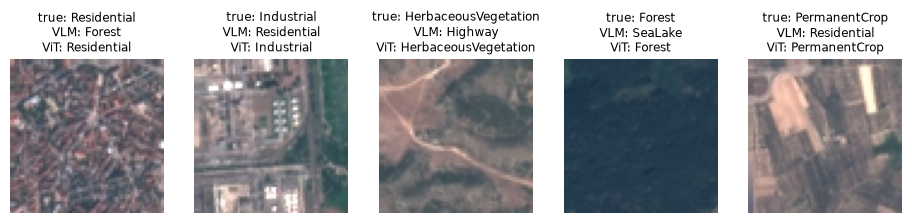

- The first five chips the VLM gets wrong, with the ViT’s answer. Read the errors, not only the rate: `Pasture` for `HerbaceousVegetation` is harmless for many uses, a lake for a forest is not

## Specialized or General?

- The ViT was trained for these ten classes and nothing else: $100$ chips in seconds, a probability per class, fixed outputs. A new question means labelling data and training again
- The VLM had no training from us. The classes are words in the prompt, and the same model answers other questions about the same chip; the table is the price
- Specialization is not automatic: Qwen3-VL loses to Qwen 3.5 4B, seven times the parameters buy nine points, ten labelled chips about as many, and only the fine-tuned ViT is reliable here

## Things to Try and Extra Materials

- Ask yes or no about roads, or for JSON attributes with `response_format={"type": "json_object"}`, and check which chips flip; try `qwen3.5:2b`, `qwen3-vl:4b-instruct`, or `qwen3.8:27b-mlx`, and thinking by dropping `reasoning_effort`
- Aggregate predictions to a region, regress an outcome on the share of built-up land, then estimate $p_0$ and $p_1$ from labelled chips and correct the slope ([classification lecture](classification.qmd#/measurement-error-from-a-classifier))
- The tables come from the committed `data/eurosat_predictions.csv`. Rebuild it with `uv run python utilities/build_eurosat_predictions.py`, then render with `--no-cache`
- References
  - [Helber, Bischke, Dengel, and Borth (2019), “EuroSAT”](https://arxiv.org/abs/1709.00029), *IEEE JSTARS*, and the [dataset on the Hub](https://huggingface.co/datasets/cm93/eurosat)
  - [Donaldson and Storeygard (2016), “The View from Above”](https://www.aeaweb.org/articles?id=10.1257/jep.30.4.171), *JEP*; [Jean et al. (2016)](https://doi.org/10.1126/science.aaf7894), *Science*, on predicting poverty from imagery
  - [Dell (2025), “Deep Learning for Economists”](https://www.aeaweb.org/articles?id=10.1257/jel.20241733), *JEL*, and [EconDL](https://econdl.github.io/)
  - Ollama [vision](https://docs.ollama.com/capabilities/vision) and [OpenAI compatibility](https://docs.ollama.com/api/openai-compatibility) documentation